# Rafael de Barros Leite - rafaelbarrosleite@gmail.com | | rafael.leite@gruposbf.com.br
# Tech Challenge - Fase 1 - Diagnóstico de Câncer de Mama

## O problema

Nesse desafio eu peguei o cenário do hospital que quer um sistema de IA pra ajudar na triagem dos exames. Transformei isso num problema de **classificação**: a partir das medidas de um exame, prever se o tumor de mama é **benigno** ou **maligno**.

A base que escolhi foi a **Breast Cancer Wisconsin**, que é pública e é uma das sugeridas no enunciado. Ela tem 569 registros e 30 variáveis numéricas (medidas das células, tipo raio, textura, área, etc.).

In [102]:
import pandas as pd

In [103]:
dados = pd.read_csv('data.csv')

In [104]:
dados.shape

(569, 33)

In [105]:
dados.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [106]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [107]:
set(dados.diagnosis)

{'B', 'M'}

In [108]:
dados.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## Primeira olhada nos dados

Aqui eu carreguei a base e fui entender com o que eu estava lidando: formato, tipos das colunas e as estatísticas gerais. Reparei que tem uma coluna `Unnamed: 32` que tá toda vazia e a coluna `id` que é só um identificador. As duas vou remover mais pra frente porque não ajudam na previsão.

<Axes: >

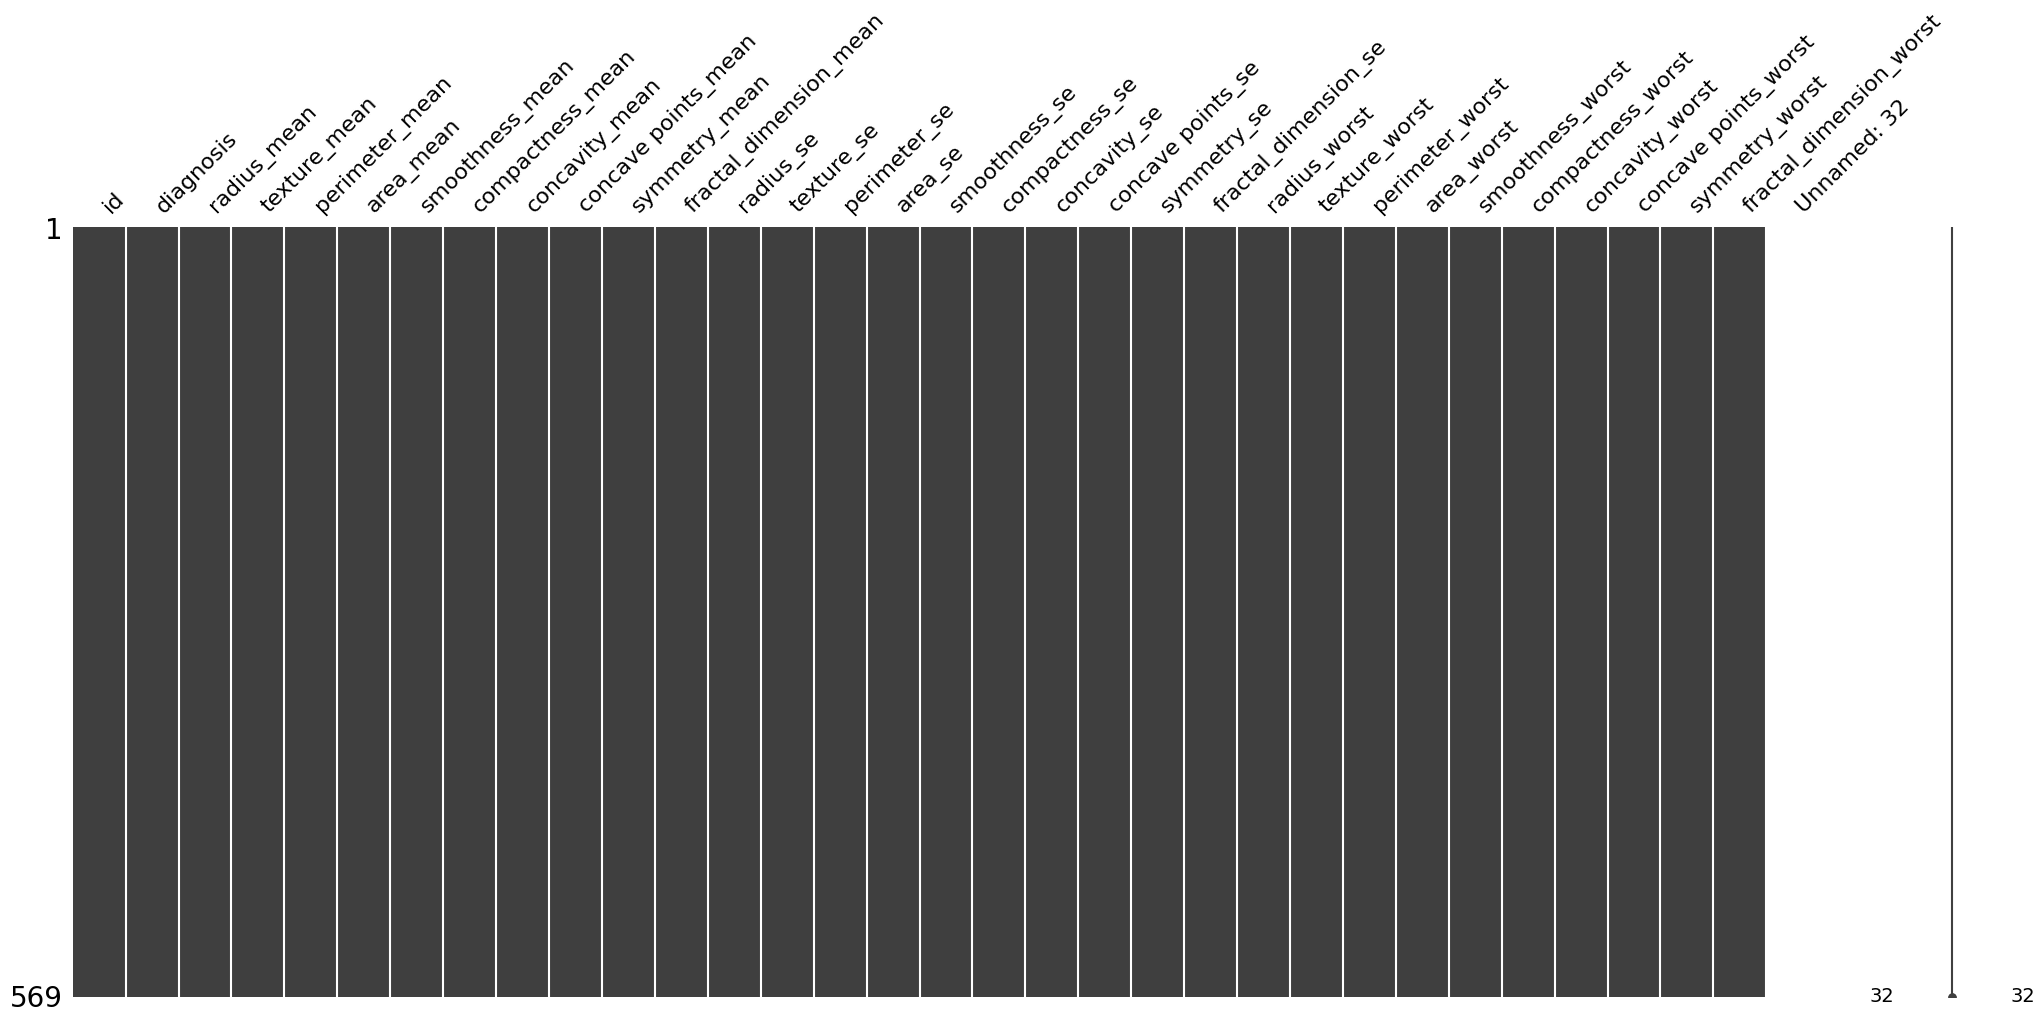

In [109]:
import missingno as msno
msno.matrix(dados)

In [110]:
dados.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [111]:
import seaborn as sb

/tmp/ipykernel_1659/733029712.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='diagnosis', y='texture_mean', data=dados, palette='hls')


<Axes: xlabel='diagnosis', ylabel='texture_mean'>

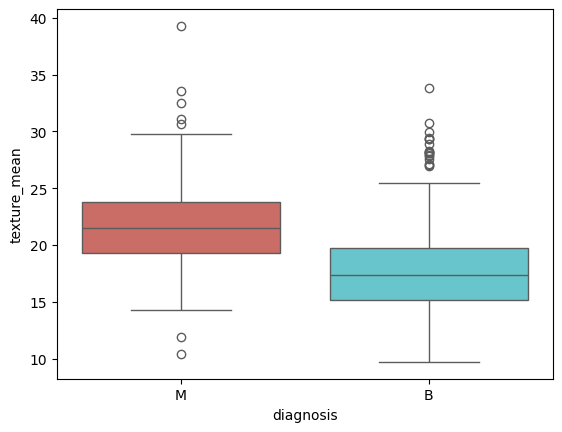

In [112]:
sb.boxplot(x='diagnosis', y='texture_mean', data=dados, palette='hls')

<Axes: xlabel='texture_mean'>

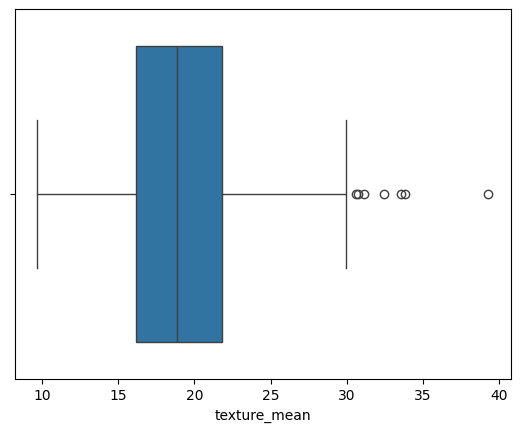

In [113]:
sb.boxplot(x=dados["texture_mean"])

In [114]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [115]:
dados = dados.drop(columns=["Unnamed: 32"])

In [116]:
dados.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [117]:
dados = dados.drop(columns=["id"])

## Limpeza dos dados

Conferi os valores ausentes com o `missingno` e com o `isnull().sum()`. Tirando a coluna `Unnamed: 32` que estava 100% vazia, **não tinha nenhum valor faltando** nas variáveis de verdade. Então não precisei fazer imputação. Removi a `Unnamed: 32` e a `id` porque não servem pra modelagem.

In [118]:
dados.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [119]:
dados["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


In [120]:
dados["diagnosis"].value_counts(normalize=True) * 100

,proportion
diagnosis,
B,62.741652
M,37.258348


In [121]:
dados["diagnosis"] = dados["diagnosis"].map({"B": 0, "M": 1})

In [122]:
dados["diagnosis"].value_counts()

,count
diagnosis,
0,357
1,212


## Convertendo o alvo e olhando o balanceamento

A única variável categórica era o `diagnosis`. Converti pra número: B = 0 (benigno) e M = 1 (maligno). Coloquei o maligno como 1 de propósito, porque é a classe que eu mais quero acertar.

Olhando o balanceamento, deu mais ou menos 63% benigno e 37% maligno. Tem um desbalanceamento, mas não é tão forte. Por garantia, vou usar `stratify` na hora de dividir os dados pra manter essa proporção em todos os pedaços.

In [123]:
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

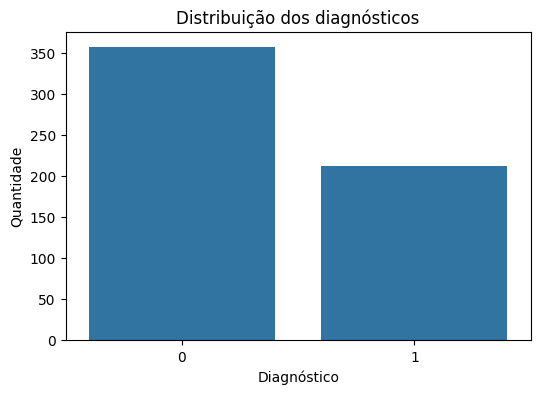

In [124]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=dados["diagnosis"]
)

plt.title("Distribuição dos diagnósticos")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade")

plt.show()

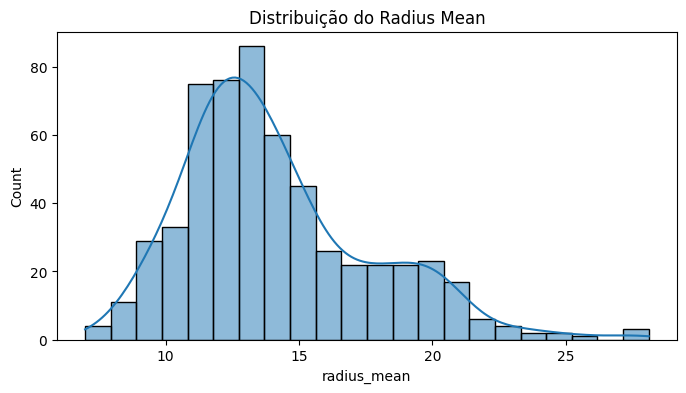

In [125]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=dados,
    x="radius_mean",
    kde=True
)

plt.title("Distribuição do Radius Mean")
plt.show()

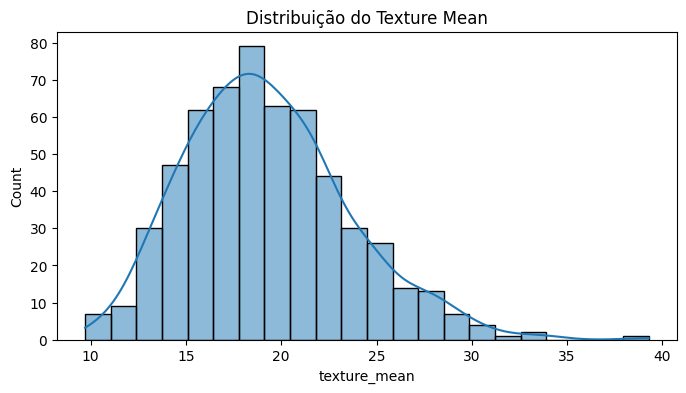

In [126]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=dados,
    x="texture_mean",
    kde=True
)

plt.title("Distribuição do Texture Mean")
plt.show()

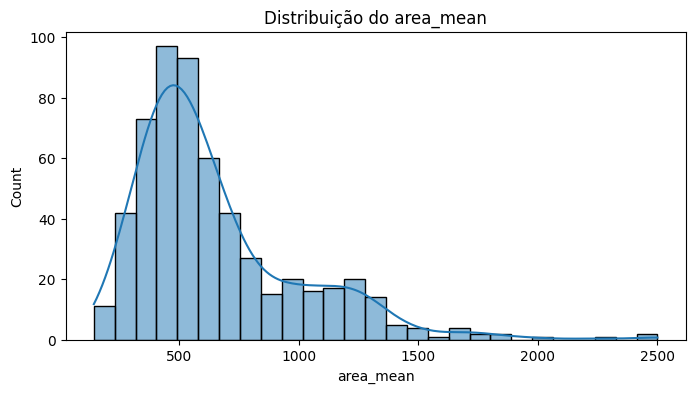

In [127]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=dados,
    x="area_mean",
    kde=True
)

plt.title("Distribuição do area_mean")
plt.show()

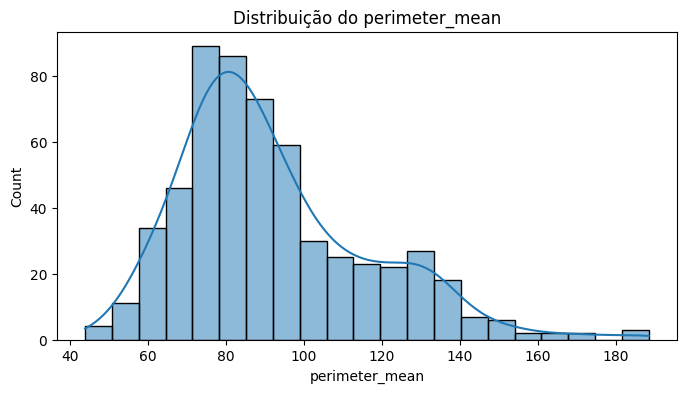

In [128]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=dados,
    x="perimeter_mean",
    kde=True
)

plt.title("Distribuição do perimeter_mean")
plt.show()

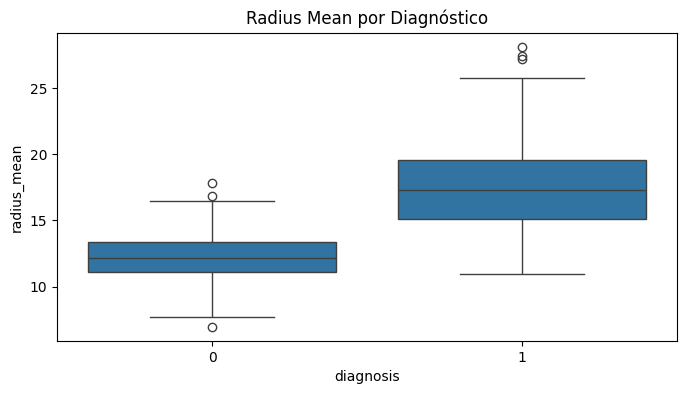

In [129]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=dados,
    x="diagnosis",
    y="radius_mean"
)

plt.title("Radius Mean por Diagnóstico")

plt.show()

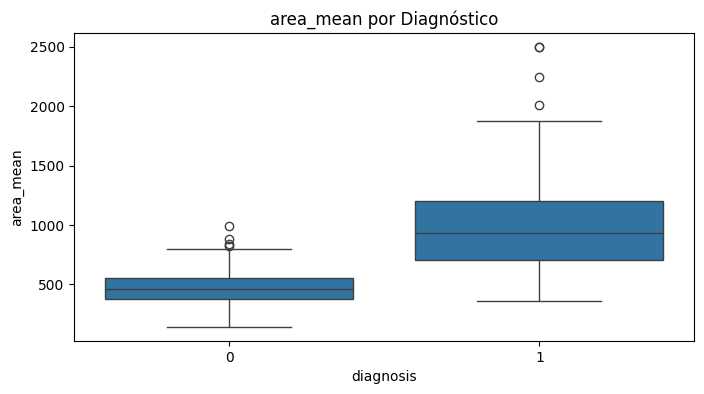

In [130]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=dados,
    x="diagnosis",
    y="area_mean"
)

plt.title("area_mean por Diagnóstico")

plt.show()

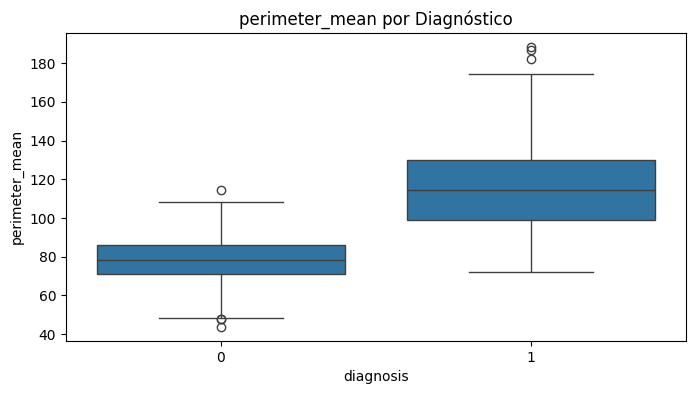

In [131]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=dados,
    x="diagnosis",
    y="perimeter_mean"
)

plt.title("perimeter_mean por Diagnóstico")

plt.show()

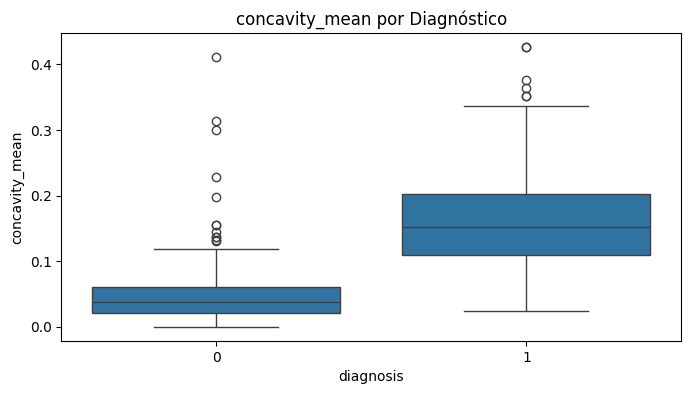

In [132]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=dados,
    x="diagnosis",
    y="concavity_mean"
)

plt.title("concavity_mean por Diagnóstico")

plt.show()

In [133]:
corr = dados.corr()

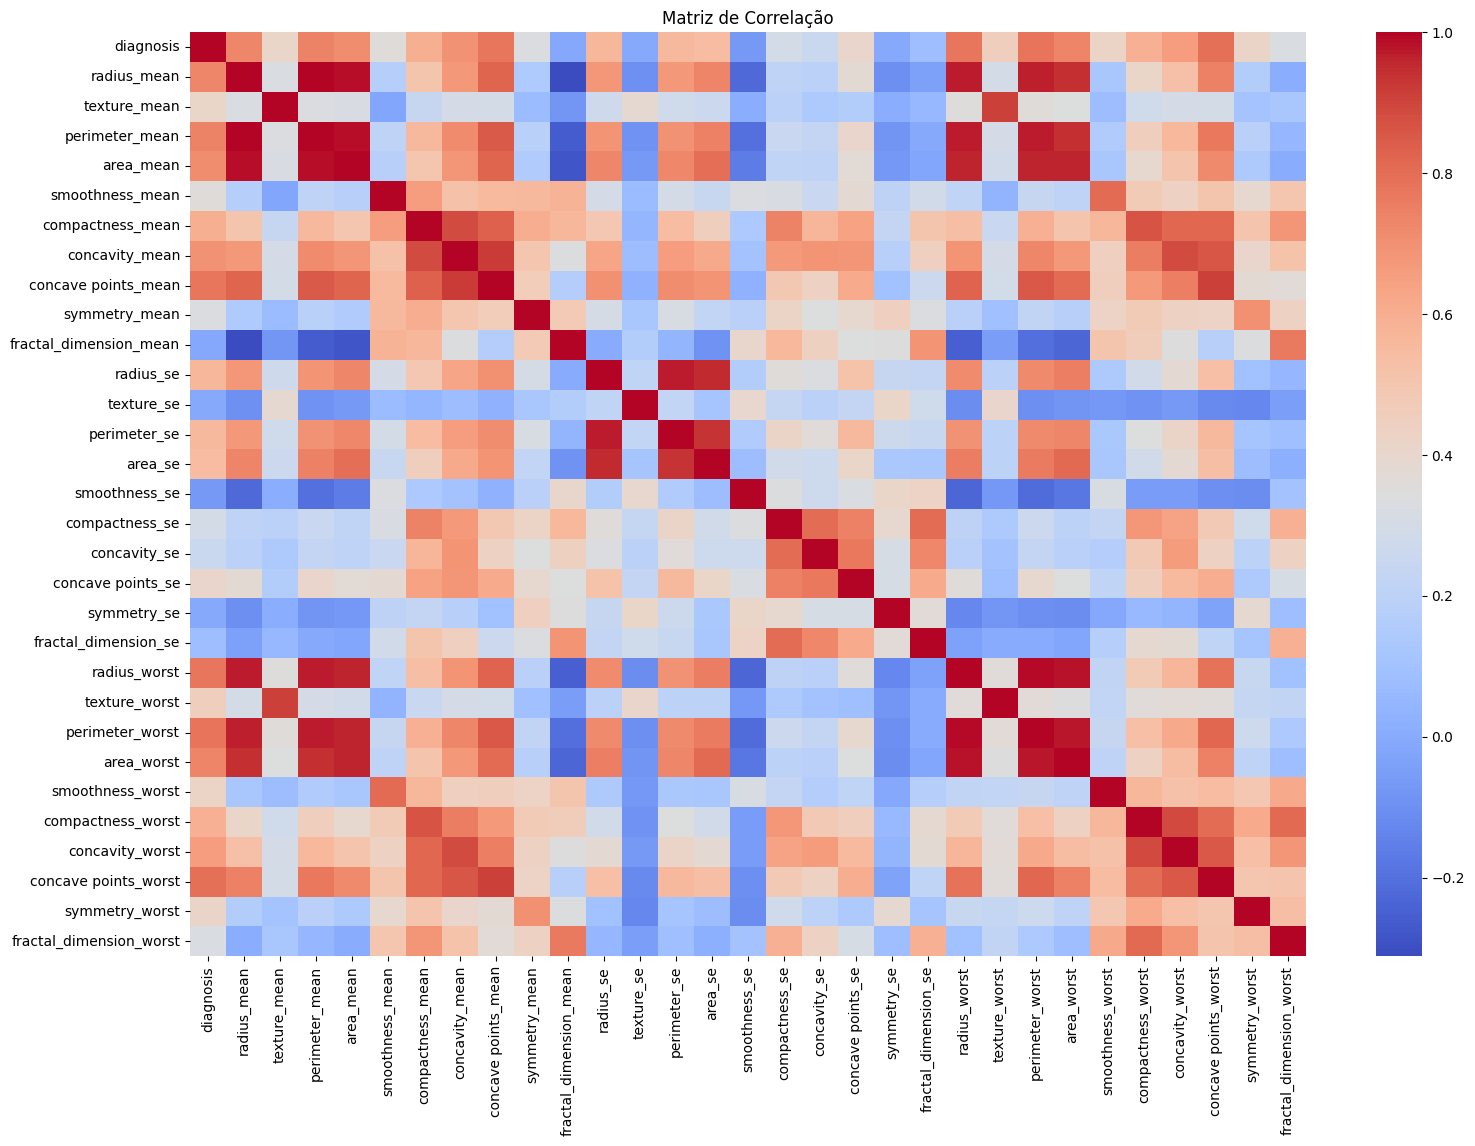

In [134]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Matriz de Correlação")

plt.show()

In [135]:
corr_target = (
    dados.corr()["diagnosis"]
      .sort_values(ascending=False)
)

corr_target

,diagnosis
diagnosis,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


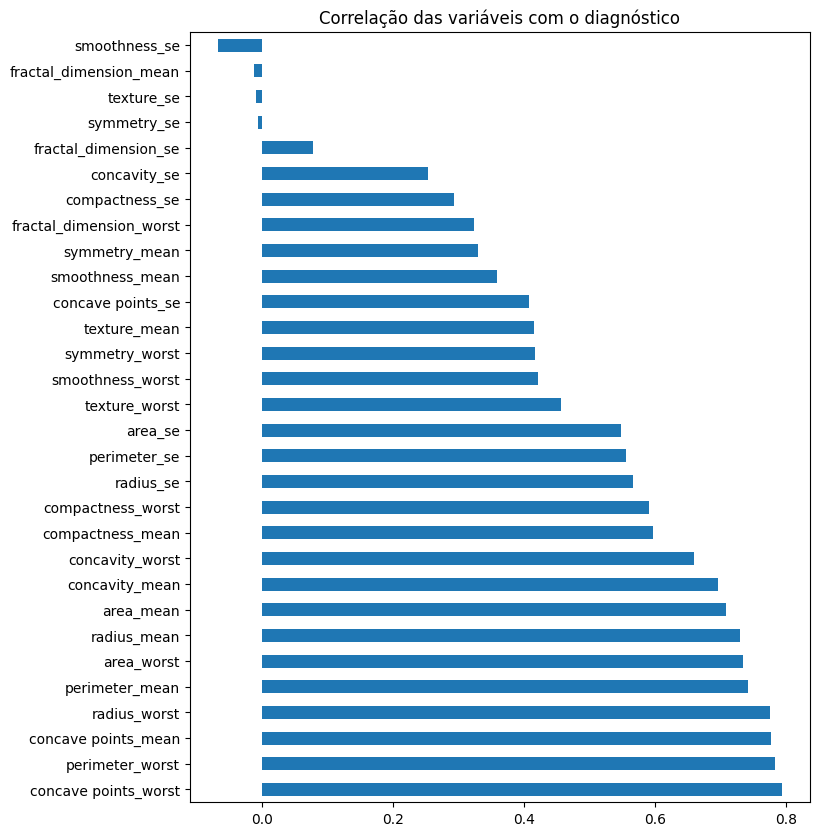

In [136]:
plt.figure(figsize=(8,10))

corr_target.drop("diagnosis").plot(kind="barh")

plt.title("Correlação das variáveis com o diagnóstico")

plt.show()

## O que a exploração e a correlação me mostraram

Pelos histogramas e boxplots, dá pra ver que as variáveis ligadas a **tamanho e forma do tumor** (raio, perímetro, área e concavidade) costumam ter valores bem mais altos nos casos malignos. A análise de correlação confirmou isso: essas mesmas variáveis são as que têm maior correlação com o diagnóstico. Já me dá um indício de quais variáveis vão pesar mais no modelo.

(Reparei também que várias variáveis são muito parecidas entre si - raio, perímetro e área medem quase a mesma coisa. Isso não atrapalha a acurácia, mas é bom ter em mente na hora de interpretar.)

In [137]:
X = dados.drop(columns=["diagnosis"])
y = dados["diagnosis"]

In [138]:
from sklearn.model_selection import train_test_split

In [139]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

##Split 1
test_size=0.20: separa a base toda em duas partes.



*   X_train_val = 80% dos dados
*   X_test = 20% dos dados




In [140]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

##Split 2
test_size=0.25: pega só os 80% do X_train_val e divide de novo.


*   X_val = 25% de 80% = 0,25 × 80% = 20% do total
*   X_train = 75% de 80% = 0,75 × 80% = 60% do total






In [141]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(341, 30)
(114, 30)
(114, 30)


## Por que dividi em treino, validação e teste

Separei os dados em três partes: 60% treino, 20% validação e 20% teste, usando `stratify` pra manter a proporção de benignos/malignos em cada um.

A lógica é: uso o **treino** pra ensinar os modelos, a **validação** pra comparar os modelos e escolher o melhor, e o **teste** fica guardado só pro final, pra medir o desempenho real em dados que o modelo nunca viu. Assim eu não "trapaceio" olhando o teste o tempo todo.

## Qual métrica eu vou priorizar (e por quê)

Esse ponto é o mais importante do trabalho pra mim. Em diagnóstico, nem todo erro é igual:

- Falso positivo (dizer maligno e ser benigno): gera susto e exame a mais, mas é contornável.
- Falso negativo (dizer benigno e ser maligno): é muito mais grave, porque atrasa o tratamento de quem precisava.

Por isso, a métrica que vou priorizar é o **Recall da classe maligna**, que **mede quantos dos tumores malignos reais o modelo consegue pegar**. Vou olhar accuracy e F1 também, mas quem decide o modelo final é o recall. Acurácia sozinha engana em base desbalanceada.

In [142]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

Criando o pipeline

In [143]:
modelo_logistico = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

Treinar modelo

In [144]:
modelo_logistico.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

Fazer previsão na validação

In [145]:
y_pred_val = modelo_logistico.predict(X_val)

In [146]:
y_pred_val

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1])

In [147]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

In [148]:
accuracy = accuracy_score(y_val, y_pred_val)

precision = precision_score(y_val, y_pred_val)

recall = recall_score(y_val, y_pred_val)

f1 = f1_score(y_val, y_pred_val)

In [149]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Accuracy: 0.9736842105263158
Precision: 0.9545454545454546
Recall: 0.9767441860465116
F1: 0.9655172413793104


In [150]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_pred_val
    )
)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [151]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val,
    y_pred_val
)

cm

array([[69,  2],
       [ 1, 42]])

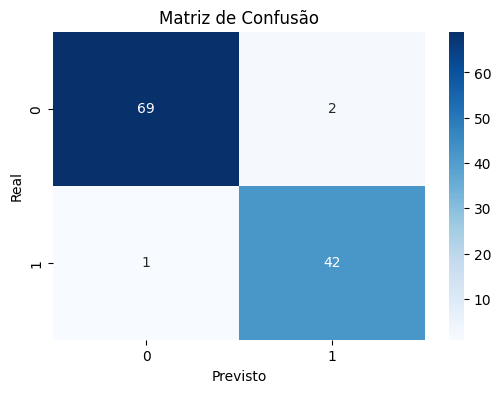

In [152]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Previsto")
plt.ylabel("Real")

plt.title("Matriz de Confusão")

plt.show()

Random Forest

In [153]:
from sklearn.ensemble import RandomForestClassifier

In [154]:
modelo_rf = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

In [155]:
modelo_rf.fit(X_train, y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [156]:
y_pred_rf_val = modelo_rf.predict(X_val)

In [157]:
print("Accuracy:", accuracy_score(y_val, y_pred_rf_val))
print("Precision:", precision_score(y_val, y_pred_rf_val))
print("Recall:", recall_score(y_val, y_pred_rf_val))
print("F1:", f1_score(y_val, y_pred_rf_val))

Accuracy: 0.9736842105263158
Precision: 0.9761904761904762
Recall: 0.9534883720930233
F1: 0.9647058823529412


In [158]:
print(classification_report(y_val, y_pred_rf_val))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



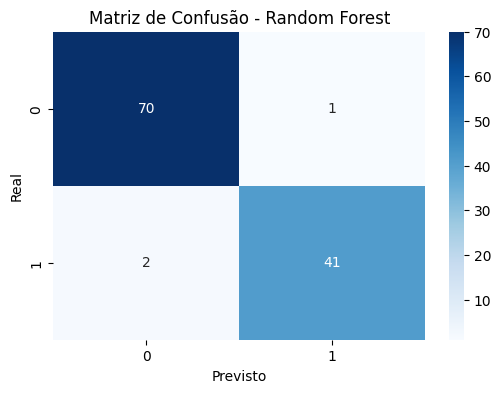

In [159]:
cm_rf = confusion_matrix(y_val, y_pred_rf_val)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest")

plt.show()

In [160]:
from sklearn.neighbors import KNeighborsClassifier

In [161]:
modelo_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [162]:
modelo_knn.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [163]:
y_pred_knn = modelo_knn.predict(X_val)

In [164]:
print(classification_report(y_val, y_pred_knn))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [165]:
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(
    y_val,
    y_pred_knn
)

cm_knn

array([[71,  0],
       [ 3, 40]])

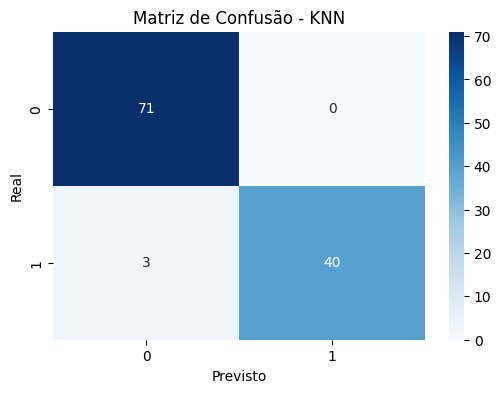

In [166]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Previsto")
plt.ylabel("Real")

plt.title("Matriz de Confusão - KNN")

plt.show()

In [167]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_val, y_pred_knn))
print("Precision:", precision_score(y_val, y_pred_knn))
print("Recall:", recall_score(y_val, y_pred_knn))
print("F1:", f1_score(y_val, y_pred_knn))

print(classification_report(y_val, y_pred_knn))

Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9302325581395349
F1: 0.963855421686747
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [168]:
for k in [3,5,7,9,11]:

    modelo_knn = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])

    modelo_knn.fit(X_train, y_train)

    pred = modelo_knn.predict(X_val)

    print(
        f"K={k}",
        "Recall:",
        recall_score(y_val, pred),
        "Accuracy:",
        accuracy_score(y_val, pred)
    )

K=3 Recall: 0.9302325581395349 Accuracy: 0.9649122807017544
K=5 Recall: 0.9302325581395349 Accuracy: 0.9736842105263158
K=7 Recall: 0.9302325581395349 Accuracy: 0.9736842105263158
K=9 Recall: 0.9302325581395349 Accuracy: 0.9736842105263158
K=11 Recall: 0.9302325581395349 Accuracy: 0.9736842105263158


In [169]:
error = []

for k in range(1, 21):

    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_val)

    error.append(
        1 - accuracy_score(y_val, pred)
    )

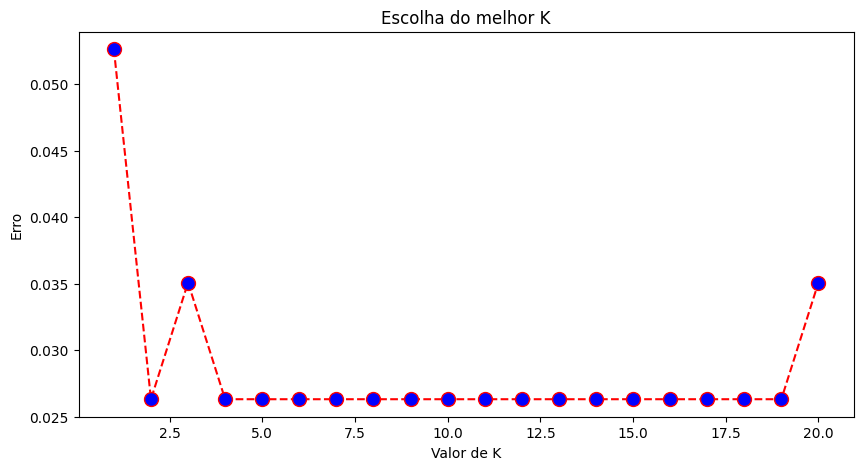

In [170]:
plt.figure(figsize=(10,5))

plt.plot(
    range(1,21),
    error,
    color='red',
    linestyle='dashed',
    marker="o",
    markerfacecolor='blue', markersize=10
)

plt.xlabel("Valor de K")
plt.ylabel("Erro")

plt.title("Escolha do melhor K")

plt.show()




##Comparação dos modelos

In [171]:
resultados = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest", "KNN"],
    "Accuracy": [
        accuracy_score(y_val, y_pred_val),
        accuracy_score(y_val, y_pred_rf_val),
        accuracy_score(y_val, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_val, y_pred_val),
        precision_score(y_val, y_pred_rf_val),
        precision_score(y_val, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_val, y_pred_val),
        recall_score(y_val, y_pred_rf_val),
        recall_score(y_val, y_pred_knn)
    ],
    "F1-score": [
        f1_score(y_val, y_pred_val),
        f1_score(y_val, y_pred_rf_val),
        f1_score(y_val, y_pred_knn)
    ]
}).sort_values("Recall", ascending=False)

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regressão Logística,0.973684,0.954545,0.976744,0.965517
1,Random Forest,0.973684,0.976190,0.953488,0.964706
2,KNN,0.973684,1.000000,0.930233,0.963855


## Modelo escolhido

Olhando a tabela acima, principalmente pela coluna de **Recall** (que é a métrica que eu priorizei), escolhi a **Regressão Logística** como modelo final. Além de ter um bom recall, ela é a mais simples de interpretar, o que conta muito num contexto médico onde é importante explicar a previsão. Agora vou avaliar só ela no conjunto de teste.

In [172]:
importancias = modelo_rf.named_steps["model"].feature_importances_

In [173]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importancias
})

In [174]:
feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
)

In [175]:
feature_importance.head(10)

,Feature,Importance
22,perimeter_worst,0.153523
7,concave points_mean,0.118497
27,concave points_worst,0.113136
23,area_worst,0.103532
0,radius_mean,0.065136
6,concavity_mean,0.059937
20,radius_worst,0.057132
2,perimeter_mean,0.052675
26,concavity_worst,0.036161
3,area_mean,0.034976


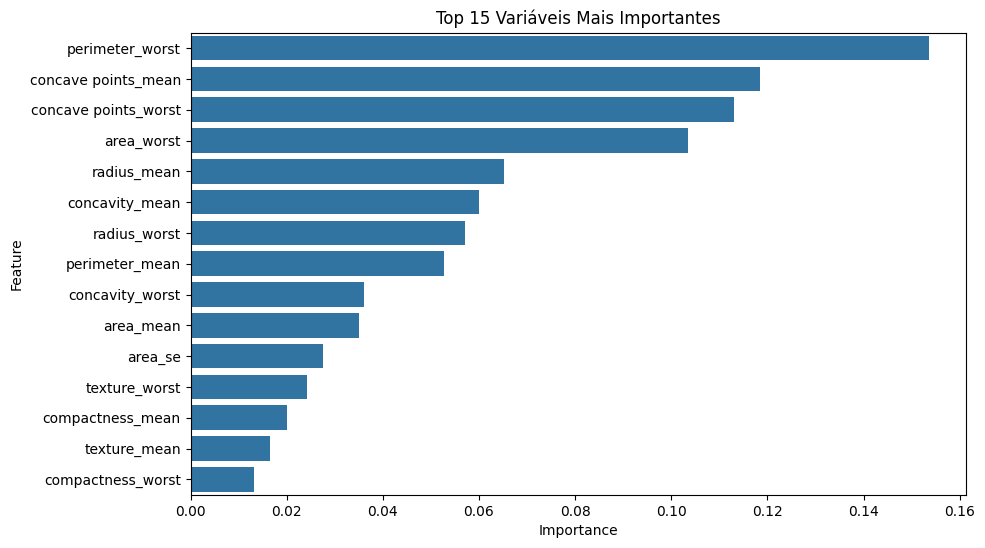

In [176]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Variáveis Mais Importantes")

plt.show()

In [177]:
feature_importance["Importance_Acumulada"] = (
    feature_importance["Importance"]
    .cumsum()
)

In [178]:
feature_importance.head(20)

,Feature,Importance,Importance_Acumulada
22,perimeter_worst,0.153523,0.153523
7,concave points_mean,0.118497,0.272020
27,concave points_worst,0.113136,0.385157
23,area_worst,0.103532,0.488689
0,radius_mean,0.065136,0.553824
6,concavity_mean,0.059937,0.613761
20,radius_worst,0.057132,0.670893
2,perimeter_mean,0.052675,0.723568
26,concavity_worst,0.036161,0.759730
3,area_mean,0.034976,0.794706


In [179]:
!pip install shap

In [180]:
import shap

In [181]:
rf_model = modelo_rf.named_steps["model"]

In [182]:
explainer = shap.TreeExplainer(rf_model)

In [183]:
shap_values = explainer.shap_values(X_val)

In [184]:
shap_values.shape

(114, 30, 2)

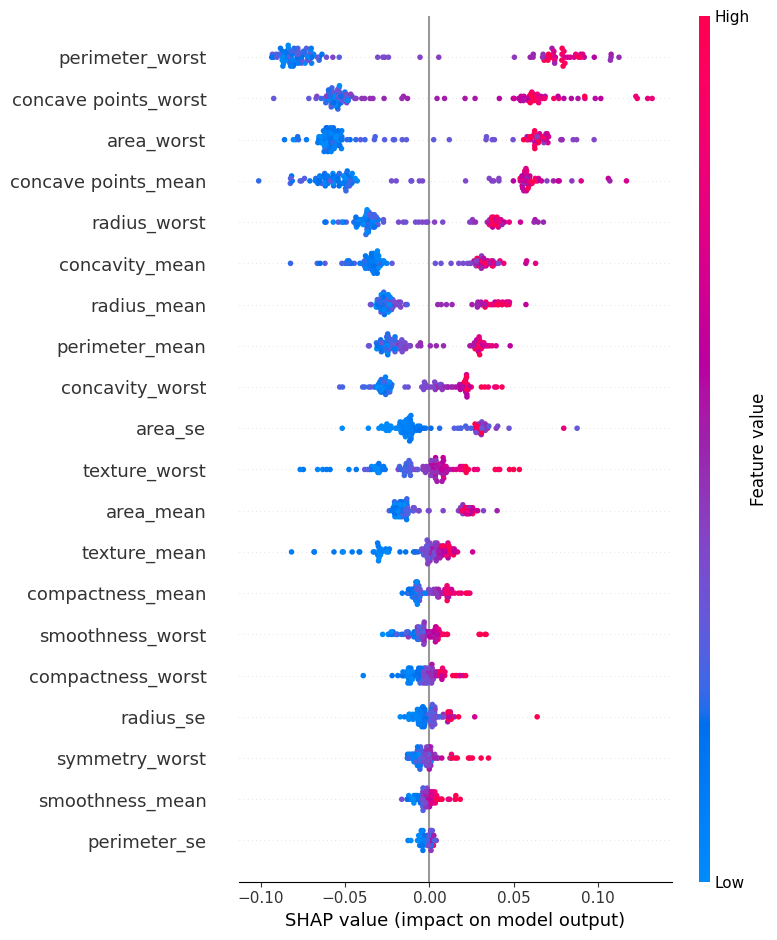

In [185]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_val,
    plot_type="dot"
)

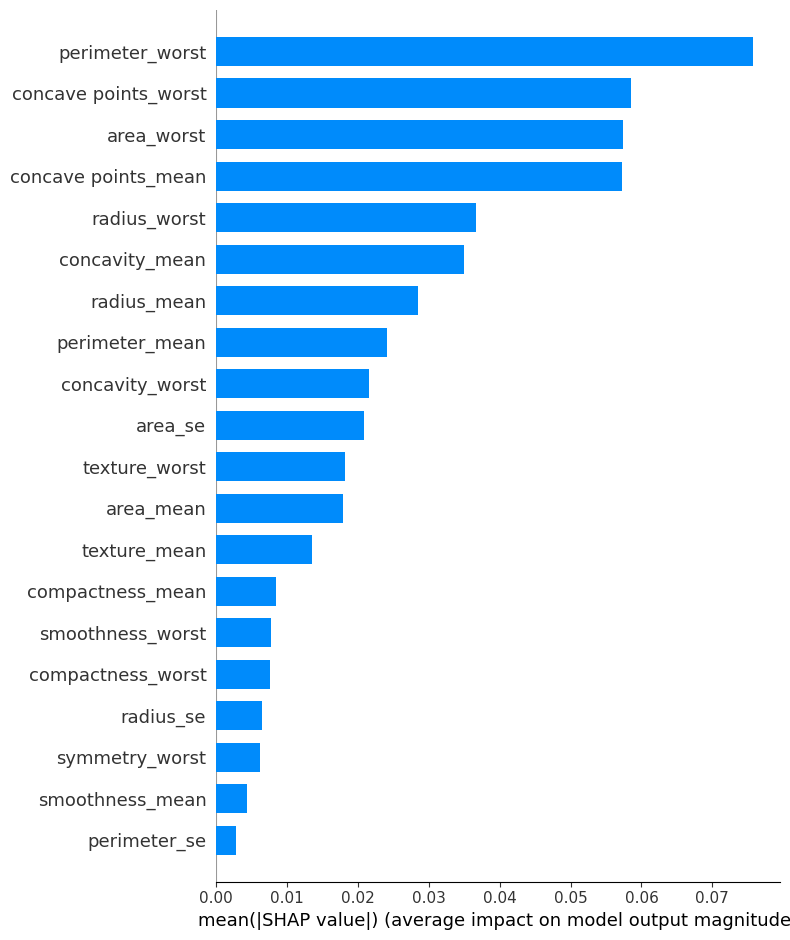

In [186]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_val,
    plot_type="bar"
)

In [187]:
explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_val)

print(shap_values.values.shape)

(114, 30, 2)


In [188]:
shap_values_maligno = shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[:, 1],
    data=shap_values.data,
    feature_names=X_val.columns
)

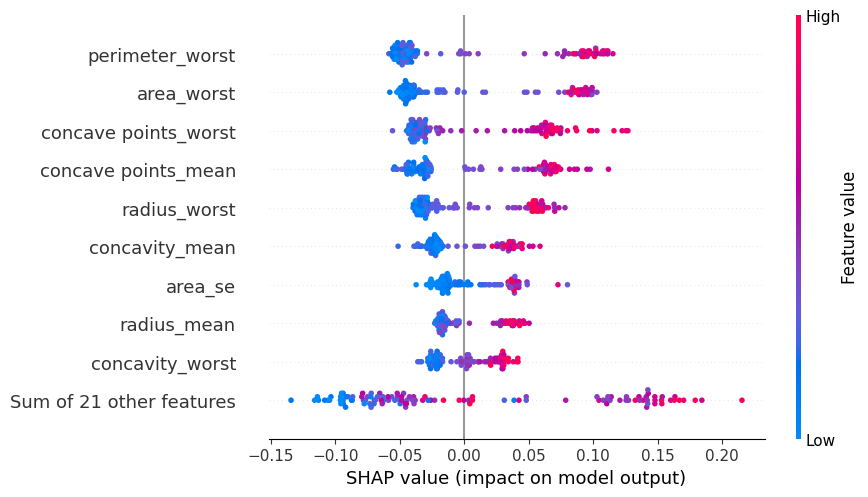

In [189]:
shap.plots.beeswarm(shap_values_maligno)

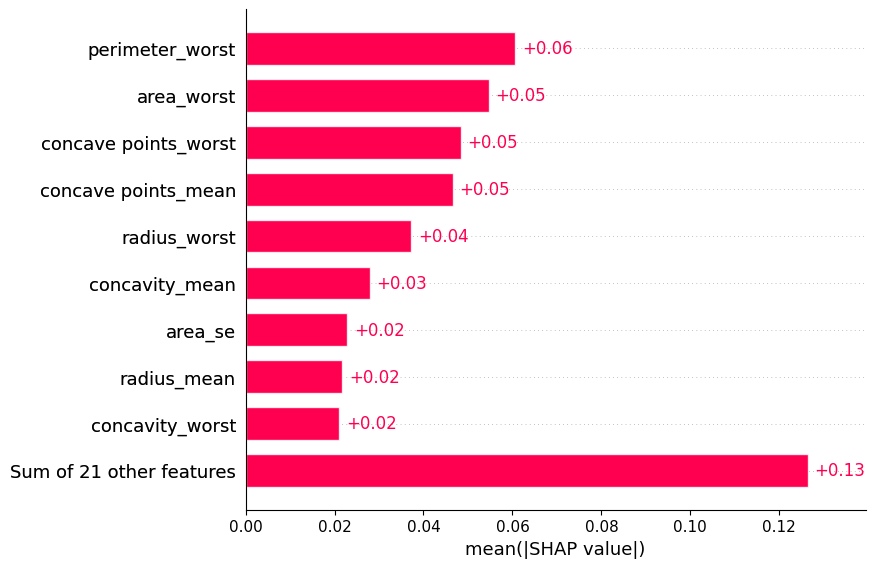

In [190]:
shap.plots.bar(shap_values_maligno)

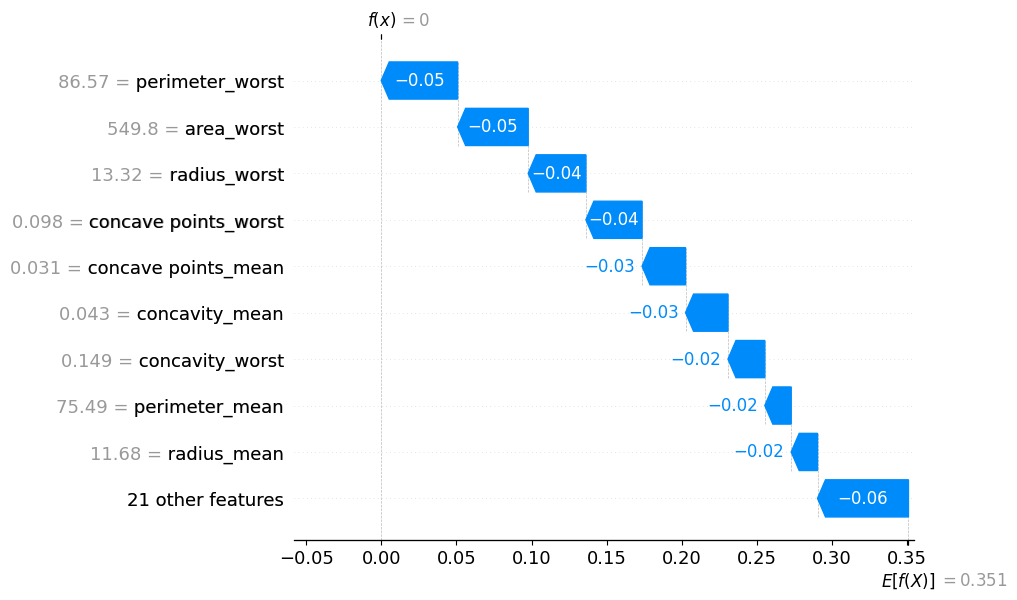

In [191]:
paciente = 0

shap.plots.waterfall(shap_values_maligno[paciente])

## Interpretando o que o modelo aprendeu

Usei duas técnicas pra entender o modelo. O **feature importance** do Random Forest e o **SHAP** contaram a mesma história: as variáveis que mais pesam são as de tamanho e forma do tumor (concave points, perimeter, radius, area). O SHAP ainda mostra a direção - valores altos dessas variáveis empurram a previsão pra "maligno". E com o gráfico de waterfall dá pra explicar um paciente individual, o que seria ótimo pra mostrar pro médico o porquê de cada previsão.

O legal é que isso bate com o conhecimento clínico (tumor maligno tende a ser maior e com bordas mais irregulares), então o modelo não está aprendendo bobagem.

In [192]:
modelo_final = modelo_logistico

In [193]:
coeficientes = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente": modelo_logistico.named_steps["model"].coef_[0]
}).sort_values("Coeficiente", ascending=False)

coeficientes.head(10)

,Feature,Coeficiente
21,texture_worst,1.355329
7,concave points_mean,1.104290
10,radius_se,1.025939
28,symmetry_worst,0.951861
20,radius_worst,0.813413
23,area_worst,0.794784
13,area_se,0.782246
26,concavity_worst,0.768948
6,concavity_mean,0.762093
22,perimeter_worst,0.661707


In [194]:
y_pred_test = modelo_final.predict(X_test)

In [195]:
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1:", f1_score(y_test, y_pred_test))

print(classification_report(y_test, y_pred_test))

Accuracy: 0.9736842105263158
Precision: 0.975609756097561
Recall: 0.9523809523809523
F1: 0.963855421686747
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



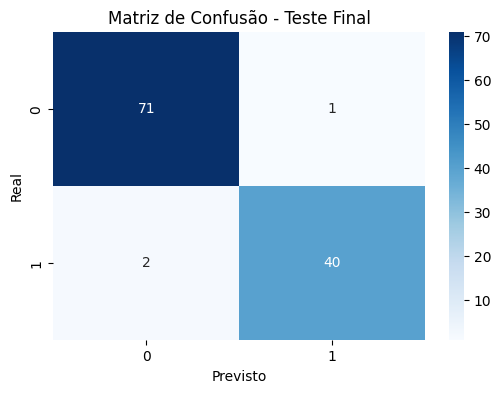

In [196]:
cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Teste Final")

plt.show()

In [197]:
probabilidades = modelo_final.predict_proba(X_test)

probabilidades[:5]

array([[9.99531338e-01, 4.68662215e-04],
       [2.48008540e-08, 9.99999975e-01],
       [9.55243640e-01, 4.47563598e-02],
       [2.91478613e-01, 7.08521387e-01],
       [3.30097907e-01, 6.69902093e-01]])

In [198]:
resultado_teste = X_test.copy()

resultado_teste["diagnostico_real"] = y_test
resultado_teste["diagnostico_previsto"] = y_pred_test
resultado_teste["probabilidade_benigno"] = probabilidades[:, 0]
resultado_teste["probabilidade_maligno"] = probabilidades[:, 1]

resultado_teste.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnostico_real,diagnostico_previsto,probabilidade_benigno,probabilidade_maligno
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523,0,0,9.995313e-01,0.000469
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849,1,1,2.480085e-08,1.000000
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960,0,0,9.552436e-01,0.044756
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353,1,1,2.914786e-01,0.708521
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,0,1,3.300979e-01,0.669902


## Discussão crítica - dá pra usar na prática?

Na minha opinião dá pra usar, mas **como apoio, nunca como decisão final**.

- Como eu usaria: o modelo roda junto com o exame e sinaliza os casos com alta chance de malignidade pra serem priorizados na fila do médico. Funciona como um "segundo olhar" automático.
- Cuidados: o dataset é pequeno e de uma fonte específica. Antes de usar de verdade, precisaria validar com os dados do próprio hospital e acompanhar se continua funcionando bem.
- Responsabilidade: em saúde, erro tem consequência séria. Por isso o médico revisa sempre. O sistema ajuda a ganhar tempo e a não deixar passar caso suspeito, mas a palavra final é sempre humana.

## Conclusão

Consegui montar a base do sistema: explorei os dados, fiz a limpeza, treinei e comparei três modelos, escolhi o melhor com base no recall (que é a métrica que faz sentido aqui) e interpretei os resultados com feature importance e SHAP. Deu um resultado bom e, com os cuidados certos, pode servir como ferramenta de triagem.